# Reflected Wave Test — Results Visualization

This notebook plots the two-layer velocity model and the computed traveltimes (direct P, PmP, PmS)
from the TOMOATT reflection test. It also compares computed PmP traveltimes against the analytical
flat-layer formula.

In [1]:
import numpy as np
import h5py
import math
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

R_earth = 6371.0
nr, nt, np_ = 41, 41, 41  # grid dimensions (r, theta, phi)

# Source and model parameters
src_lat, src_lon, src_dep = 1.0, 1.0, 5.0  # degrees, degrees, km
moho_depth = 35.0  # km
Vp1 = 6.0  # km/s (layer 1)
Vs1 = 3.5  # km/s (layer 1)

## 1. Load Grid Coordinates and Model / Traveltime Data

In [2]:
# Load grid coordinates
with h5py.File('OUTPUT_FILES/out_data_grid.h5', 'r') as f:
    r_flat = f['Mesh/node_coords_r'][:]   # radius in km
    t_flat = f['Mesh/node_coords_t'][:]   # latitude in degrees
    p_flat = f['Mesh/node_coords_p'][:]   # longitude in degrees

# Load model and traveltime fields
with h5py.File('OUTPUT_FILES/out_data_sim_group_0.h5', 'r') as f:
    vel_flat  = f['model/vel_inv_0000'][:]                          # P-velocity
    T_direct  = f['src_100001/time_field_inv_0000'][:]              # direct P
    T_PmP     = f['src_100001/phase_PmP/time_field_inv_0000'][:]   # PmP
    T_PmS     = f['src_100001/phase_PmS/time_field_inv_0000'][:]   # PmS

# Reshape from flat (nr*nt*np,) to 3-D (nr, nt, np)
# Ordering: r slowest, phi fastest
r_3d   = r_flat.reshape(nr, nt, np_)
t_3d   = t_flat.reshape(nr, nt, np_)
p_3d   = p_flat.reshape(nr, nt, np_)
vel_3d = vel_flat.reshape(nr, nt, np_)
Td_3d  = T_direct.reshape(nr, nt, np_)
Tp_3d  = T_PmP.reshape(nr, nt, np_)
Ts_3d  = T_PmS.reshape(nr, nt, np_)

# 1-D coordinate arrays
rr  = r_3d[:, 0, 0]          # radius (km)
dep = R_earth - rr            # depth (km)
lat = t_3d[0, :, 0]          # latitude (deg)
lon = p_3d[0, 0, :]          # longitude (deg)

print(f'Depth range : {dep.min():.1f} – {dep.max():.1f} km  (nr={nr})')
print(f'Lat   range : {lat.min():.2f} – {lat.max():.2f} deg (nt={nt})')
print(f'Lon   range : {lon.min():.2f} – {lon.max():.2f} deg (np={np_})')

Depth range : -5.0 – 75.0 km  (nr=41)
Lat   range : 0.00 – 2.00 deg (nt=41)
Lon   range : 0.00 – 2.00 deg (np=41)


## 2. Velocity Model — Cross-section at lat = 1.0°

Depth-vs-longitude cross-section through the source latitude, showing the two-layer
Vp model with the Moho at 35 km depth.

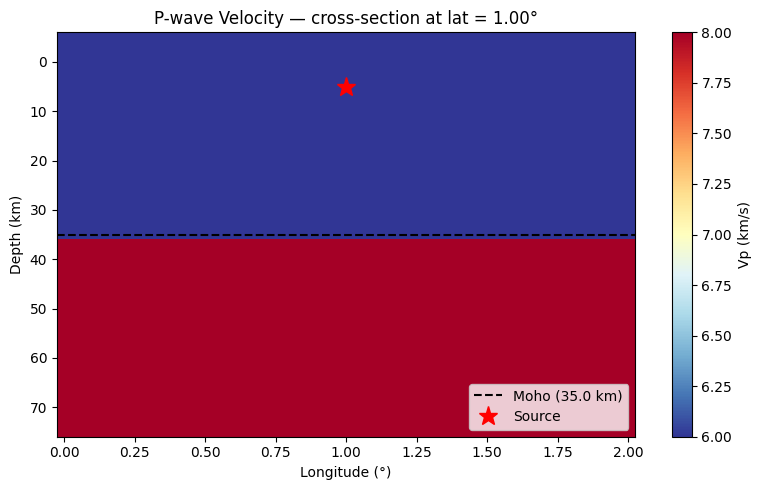

In [3]:
# Find the latitude index closest to src_lat
jlat = np.argmin(np.abs(lat - src_lat))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(lon, dep, vel_3d[:, jlat, :],
                   shading='auto', cmap='RdYlBu_r')
ax.axhline(moho_depth, color='k', ls='--', lw=1.5, label=f'Moho ({moho_depth} km)')
ax.plot(src_lon, src_dep, 'r*', ms=14, zorder=5, label='Source')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Depth (km)')
ax.set_title(f'P-wave Velocity — cross-section at lat = {lat[jlat]:.2f}°')
ax.invert_yaxis()
ax.legend(loc='lower right')
cb = fig.colorbar(im, ax=ax, label='Vp (km/s)')
plt.tight_layout()
plt.show()

## 3. Traveltime Fields — Cross-sections at lat = 1.0°

Side-by-side depth–longitude cross-sections of the direct P, PmP, and PmS traveltime fields.

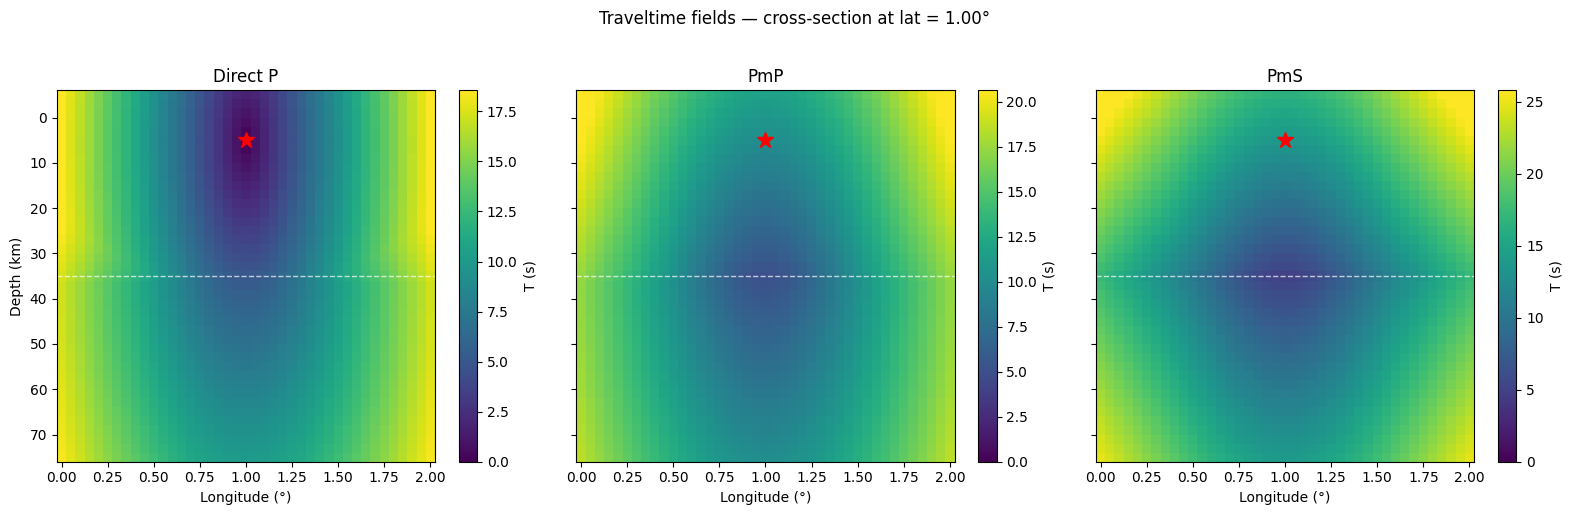

In [4]:
fields = [
    ('Direct P',  Td_3d[:, jlat, :]),
    ('PmP',       Tp_3d[:, jlat, :]),
    ('PmS',       Ts_3d[:, jlat, :]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (title, data) in zip(axes, fields):
    # Clip unreasonably large values (uninitialised regions)
    vmax = np.percentile(data[data < 1e10], 99)
    im = ax.pcolormesh(lon, dep, data,
                       shading='auto', cmap='viridis',
                       norm=Normalize(vmin=0, vmax=vmax))
    ax.axhline(moho_depth, color='w', ls='--', lw=1, alpha=0.7)
    ax.plot(src_lon, src_dep, 'r*', ms=12, zorder=5)
    ax.set_xlabel('Longitude (°)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='T (s)')

axes[0].set_ylabel('Depth (km)')
axes[0].invert_yaxis()
fig.suptitle(f'Traveltime fields — cross-section at lat = {lat[jlat]:.2f}°', y=1.02)
plt.tight_layout()
plt.show()

## 4. PmP Traveltime — Computed vs Analytical

Compare TOMOATT‐computed PmP traveltimes at the 20 surface receivers against
the analytical flat-layer formula:

$$T_{\mathrm{PmP}} = \frac{2\sqrt{h^2 + (x/2)^2}}{V_p}$$

where $h = z_{\mathrm{Moho}} - z_{\mathrm{src}}$ and $x$ is the horizontal offset.

In [5]:
# Parse computed traveltimes from the TOMOATT forward output
rec_lons_out = []
T_syn = []   # TOMOATT computed
T_obs = []   # from input (analytical estimate put in the input file)

with open('OUTPUT_FILES/src_rec_file_forward.dat', 'r') as f:
    for i, line in enumerate(f):
        if i == 0:
            continue  # source header
        parts = line.split()
        rec_lons_out.append(float(parts[4]))
        T_syn.append(float(parts[7]))
        T_obs.append(float(parts[8]))

rec_lons_out = np.array(rec_lons_out)
T_syn = np.array(T_syn)
T_obs = np.array(T_obs)

# Compute analytical PmP for a dense offset range
h = moho_depth - src_dep  # vertical distance to reflector
lon_dense = np.linspace(0.2, 1.8, 200)
offset_dense = (lon_dense - src_lon) * math.pi / 180.0 * R_earth * math.cos(math.radians(src_lat))
T_analytical_dense = 2.0 * np.sqrt(h**2 + (offset_dense / 2.0)**2) / Vp1

# Analytical at receiver positions
offset_rec = (rec_lons_out - src_lon) * math.pi / 180.0 * R_earth * math.cos(math.radians(src_lat))
T_analytical_rec = 2.0 * np.sqrt(h**2 + (offset_rec / 2.0)**2) / Vp1

print(f'Moho depth: {moho_depth} km,  Source depth: {src_dep} km,  h = {h} km')
print(f'Number of receivers: {len(rec_lons_out)}')

Moho depth: 35.0 km,  Source depth: 5.0 km,  h = 30.0 km
Number of receivers: 20


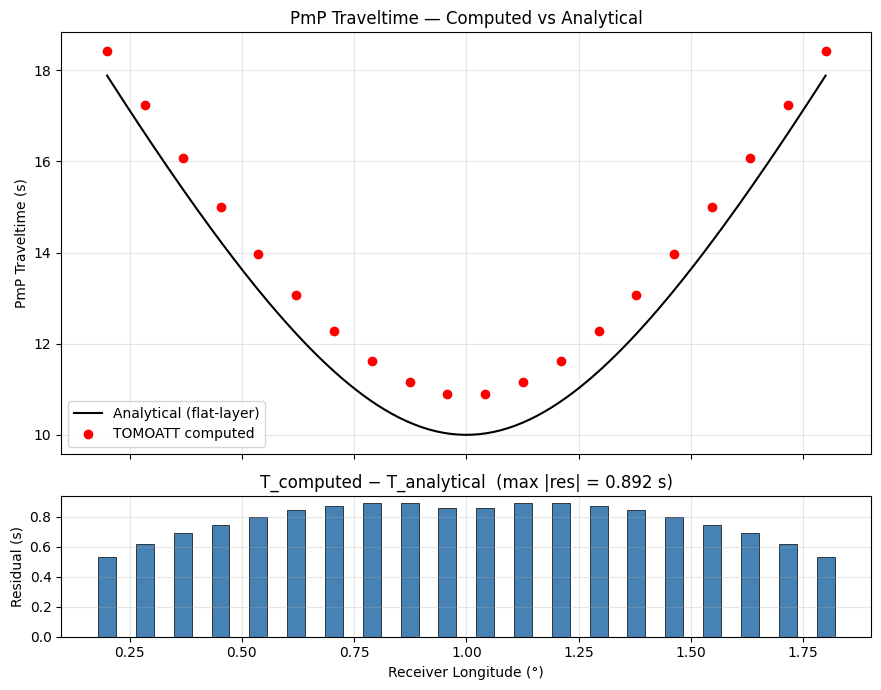

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# --- Upper panel: traveltimes ---
ax = axes[0]
ax.plot(lon_dense, T_analytical_dense, 'k-', lw=1.5, label='Analytical (flat-layer)')
ax.plot(rec_lons_out, T_syn, 'ro', ms=6, label='TOMOATT computed')
ax.set_ylabel('PmP Traveltime (s)')
ax.set_title('PmP Traveltime — Computed vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Lower panel: residuals ---
ax = axes[1]
residual = T_syn - T_analytical_rec
ax.bar(rec_lons_out, residual, width=0.04, color='steelblue', edgecolor='k', linewidth=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Receiver Longitude (°)')
ax.set_ylabel('Residual (s)')
ax.set_title(f'T_computed − T_analytical  (max |res| = {np.max(np.abs(residual)):.3f} s)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Surface Traveltime Map — Direct P and PmP at z = 0 km

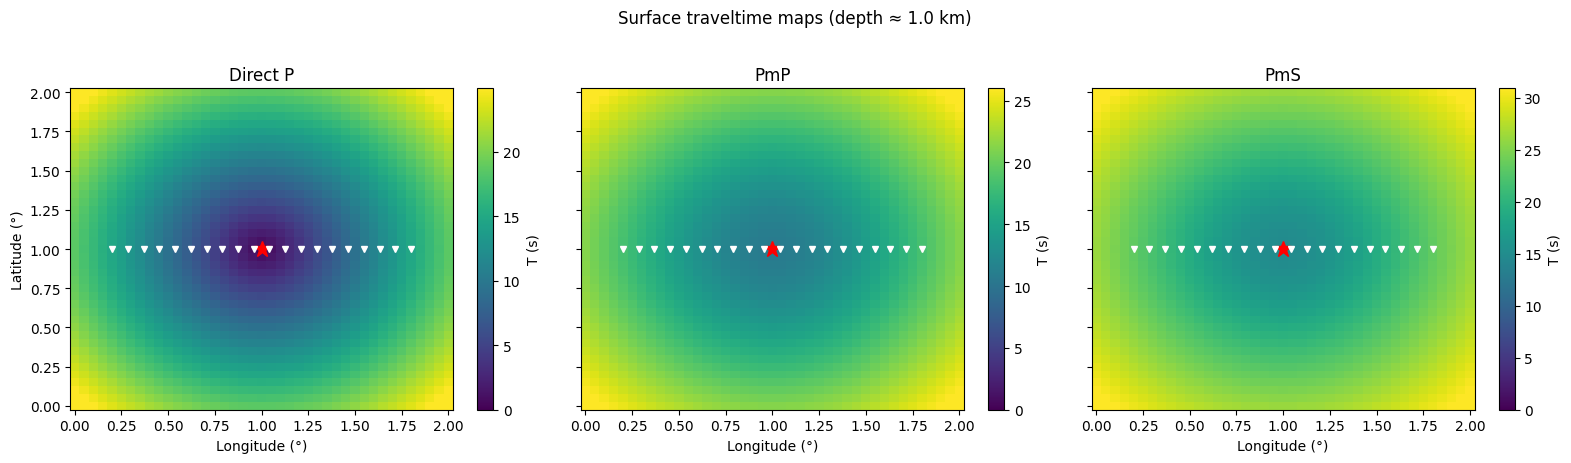

In [7]:
# Find the depth index closest to surface (depth ≈ 0 km, r ≈ R_earth)
ir_sfc = np.argmin(np.abs(dep - 0.0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (title, data3d) in zip(axes,
        [('Direct P', Td_3d), ('PmP', Tp_3d), ('PmS', Ts_3d)]):
    slab = data3d[ir_sfc, :, :]
    vmax = np.percentile(slab[slab < 1e10], 99)
    im = ax.pcolormesh(lon, lat, slab,
                       shading='auto', cmap='viridis',
                       norm=Normalize(vmin=0, vmax=vmax))
    ax.plot(src_lon, src_lat, 'r*', ms=12, zorder=5)
    ax.plot(rec_lons_out, np.full_like(rec_lons_out, src_lat), 'wv', ms=5, zorder=5)
    ax.set_xlabel('Longitude (°)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='T (s)')

axes[0].set_ylabel('Latitude (°)')
fig.suptitle(f'Surface traveltime maps (depth ≈ {dep[ir_sfc]:.1f} km)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Summary Table — Receiver Traveltimes

In [8]:
print(f'{"Rec":>6s}  {"Lon(°)":>7s}  {"Offset(km)":>11s}  {"T_analytical":>12s}  {"T_computed":>10s}  {"Residual":>10s}')
print('-' * 68)
for i in range(len(rec_lons_out)):
    print(f'{i+1:6d}  {rec_lons_out[i]:7.3f}  {offset_rec[i]:11.2f}  '
          f'{T_analytical_rec[i]:12.3f}  {T_syn[i]:10.3f}  {residual[i]:10.3f}')

   Rec   Lon(°)   Offset(km)  T_analytical  T_computed    Residual
--------------------------------------------------------------------
     1    0.200       -88.94        17.881      18.411       0.529
     2    0.284       -79.58        16.611      17.232       0.621
     3    0.368       -70.22        15.394      16.084       0.691
     4    0.453       -60.86        14.244      14.989       0.746
     5    0.537       -51.50        13.178      13.977       0.798
     6    0.621       -42.13        12.219      13.062       0.844
     7    0.705       -32.76        11.394      12.268       0.874
     8    0.789       -23.40        10.734      11.626       0.892
     9    0.874       -14.04        10.270      11.160       0.890
    10    0.958        -4.68        10.030      10.889       0.858
    11    1.042         4.68        10.030      10.889       0.858
    12    1.126        14.04        10.270      11.160       0.890
    13    1.210        23.40        10.734      11.626      